# Adversarial Examples on Logistic Regression
Logistic regression is the simplest model to which the linear explanation of adversarial examples applies **exactly**, not just locally.

We implement logistic regression here using PyTorch.

The notebook has five parts:

**Part 1 — Binary logistic regression on MNIST**

**Part 2 — Multiclass (softmax) logistic regression on MNIST**

**Part 3 — Binary Logistic Regression on STL-10**

**Part 4 — Multiclass (softmax) logistic regression on STL-10**

**Part 5 — Summary**

References: Szegedy et al. (2014), *Intriguing Properties of Neural Networks*;
Goodfellow et al. (2015), *Explaining and Harnessing Adversarial Examples*.

# 0. Setup
We rely on helper modules for most underlying functionalities: data loading, reproducibility, training, model initialization, attack implementations.

We import these helper modules as well as libraries needed for training and plotting.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from data import (
    SEED, device, train_ds, test_ds,
    train_bin, test_bin, train_loader_bin, test_loader_bin,
    train_loader, test_loader,
    make_binary_split, get_binary_val_split,
)
from models import BinaryLogReg, MulticlassLogReg
from train import train_binary_logreg, eval_binary, train_multiclass, eval_multiclass, evaluate_fgsm_binary, bce, evaluate_noise_binary, evaluate_noise_multiclass, train_binary_adversarial, train_multiclass_adversarial, evaluate_fgsm_multiclass
from attacks import fgsm_attack, gaussian_noise_attack, random_sign_attack

## 1. Reproducibility
Seeds are fixed inside `data.py` at import time. Importing `data.py` improves a reproducible data split.
## 2. Loading Data: MNIST
MNIST is downloaded and loaded inside `data.py`, which
also builds the binary and full multiclass train/test splits and
DataLoaders (`train_bin`, `test_bin`, `train_loader_bin`, `test_loader_bin`, `train_loader`, `test_loader`) used throughout this notebook.     

STL_10 is a large dataset, so we ensure it's not loaded when `data.py` is being imported but only when it's needed.

### 2.1 Data Exploration

MNIST is a standard dataset used for learning, so we only do some quick exploration/consistency check.

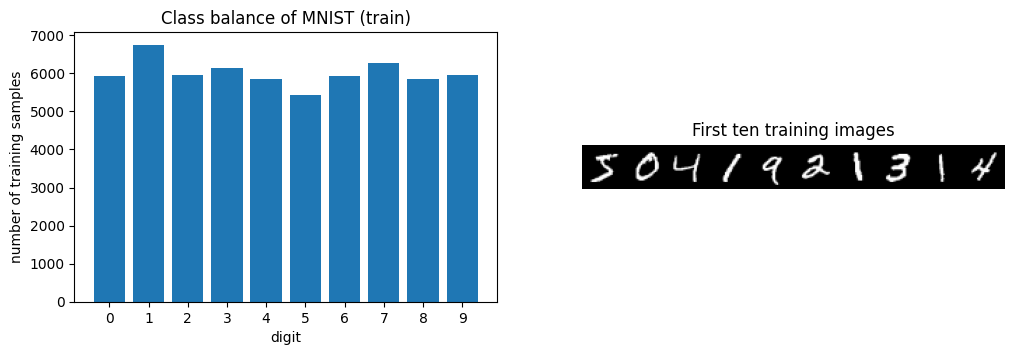

In [19]:
from torchvision.utils import make_grid

# Class balance
train_labels = train_ds.targets # all labels in dataset
counts = torch.bincount(train_labels, minlength=10) # count occurrences

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].bar(range(10), counts.numpy())
axes[0].set_xlabel("digit")
axes[0].set_ylabel("number of training samples")
axes[0].set_title("Class balance of MNIST (train)")
axes[0].set_xticks(range(10))

# Show some examples
# train_ds converted images to tensors (via the transform) for training,
# so even just to display them here, we have to convert them back
# We use make_grid, torchvision's utility for arranging a batch of
# image tensors into a single grid (see documentation).

examples = torch.stack([train_ds[i][0] for i in range(10)]) # (10, 1, 28, 28)
grid = make_grid(examples, nrow=10, padding=2) # we need a "Tensor of shape (B x C x H x W)" - https://docs.pytorch.org/vision/main/generated/torchvision.utils.make_grid.html
axes[1].imshow(grid.permute(1, 2, 0), cmap="gray")
axes[1].set_title("First ten training images")
axes[1].axis("off"); # semi-colon prevents from printing out the output

The classes are roughly balanced; each digit appears around 6000 times, so plain accuracy is a meaningful metric, we do not need class weighting.

---

# Part 1 - Binary logistic regression on MNIST
We start with restricting MNIST to digits **3** and **8** (two digits that could be confused) and relabel them as 0 and 1.
| Original digit | Mapped label |
|:---------------:|:------------:|
| 3               | 0            |
| 8               | 1            |

## Quick regularization strength search: can be skipped

In [20]:
# Check of strengths
train_sub_loader, val_sub_loader = get_binary_val_split()

alphas = [1e-5, 1e-4, 1e-3, 1e-2]

for a in alphas:
  m_l1 = train_binary_logreg(train_sub_loader, reg_type="l1", reg_strength=a, epochs=15)
  m_l2 = train_binary_logreg(train_sub_loader, reg_type="l2", reg_strength=a, epochs=15)

  l1_acc = eval_binary(m_l1, val_sub_loader)
  l2_acc = eval_binary(m_l2, val_sub_loader)
  print("alpha:", a)
  print("l1 val acc:", round(l1_acc, 4))
  print("l2 val acc:", round(l2_acc, 4))

epoch 1 | loss: 0.1872 | train acc: 0.9334
epoch 5 | loss: 0.1043 | train acc: 0.9691
epoch 10 | loss: 0.0986 | train acc: 0.9715
epoch 15 | loss: 0.0953 | train acc: 0.973
epoch 1 | loss: 0.191 | train acc: 0.9262
epoch 5 | loss: 0.1045 | train acc: 0.9696
epoch 10 | loss: 0.0983 | train acc: 0.9706
epoch 15 | loss: 0.095 | train acc: 0.9723
alpha: 1e-05
l1 val acc: 0.9716
l2 val acc: 0.9711
epoch 1 | loss: 0.1891 | train acc: 0.9326
epoch 5 | loss: 0.1124 | train acc: 0.9672
epoch 10 | loss: 0.1076 | train acc: 0.9696
epoch 15 | loss: 0.1041 | train acc: 0.9706
epoch 1 | loss: 0.1898 | train acc: 0.9216
epoch 5 | loss: 0.1052 | train acc: 0.968
epoch 10 | loss: 0.0984 | train acc: 0.9713
epoch 15 | loss: 0.0959 | train acc: 0.9718
alpha: 0.0001
l1 val acc: 0.9722
l2 val acc: 0.9716
epoch 1 | loss: 0.2243 | train acc: 0.9323
epoch 5 | loss: 0.1612 | train acc: 0.9647
epoch 10 | loss: 0.1569 | train acc: 0.9657
epoch 15 | loss: 0.1559 | train acc: 0.9678
epoch 1 | loss: 0.1954 | train 

# 1.1 Training models with no regularization, with $\ell^1$ and  $\ell^2$ regularization.

We train **three** binary models here:

1. No regularization
2. $\ell^2$ (ridge)
3. $\ell^1$ (lasso)

We predict that the lasso penalty should make the model more robust to adversarial examples.

We use the `BinaryLogReg` model and a training pipeline imported from `models.py` and `train.py` respectively.

We choose universal regularization strength to make adversarial comparisons fair. We base our choice on the quick search below:

In [21]:
print("Training unregularized model:")
model_none = train_binary_logreg(train_loader_bin, reg_type=None)

print("")

print("Training l2-regularized model:")
model_l2 = train_binary_logreg(train_loader_bin, reg_type="l2", reg_strength=1e-04)

print("")

print("Training l1-regularized model:")
model_l1 = train_binary_logreg(train_loader_bin, reg_type="l1", reg_strength=1e-04)

print("")

print("Test accuracy (none):", round(eval_binary(model_none, test_loader_bin), 4))
print("Test accuracy (l2):", round(eval_binary(model_l2, test_loader_bin), 4))
print("Test accuracy (l1):", round(eval_binary(model_l1, test_loader_bin), 4))

Training unregularized model:
epoch 1 | loss: 0.1773 | train acc: 0.9342
epoch 5 | loss: 0.1021 | train acc: 0.9691
epoch 10 | loss: 0.0957 | train acc: 0.971
epoch 15 | loss: 0.093 | train acc: 0.9725

Training l2-regularized model:
epoch 1 | loss: 0.1805 | train acc: 0.9347
epoch 5 | loss: 0.1034 | train acc: 0.9689
epoch 10 | loss: 0.0973 | train acc: 0.971
epoch 15 | loss: 0.0952 | train acc: 0.972

Training l1-regularized model:
epoch 1 | loss: 0.1853 | train acc: 0.93
epoch 5 | loss: 0.1099 | train acc: 0.968
epoch 10 | loss: 0.1047 | train acc: 0.9718
epoch 15 | loss: 0.1033 | train acc: 0.9719

Test accuracy (none): 0.9677
Test accuracy (l2): 0.9698
Test accuracy (l1): 0.9672


We got really nice results for all models, regularization did not affect accuracy.

## 1.2 Looking at the weight vectors
We visualize weights. Red/blue regions show pixels that push predictions towards 8 or towards 3.

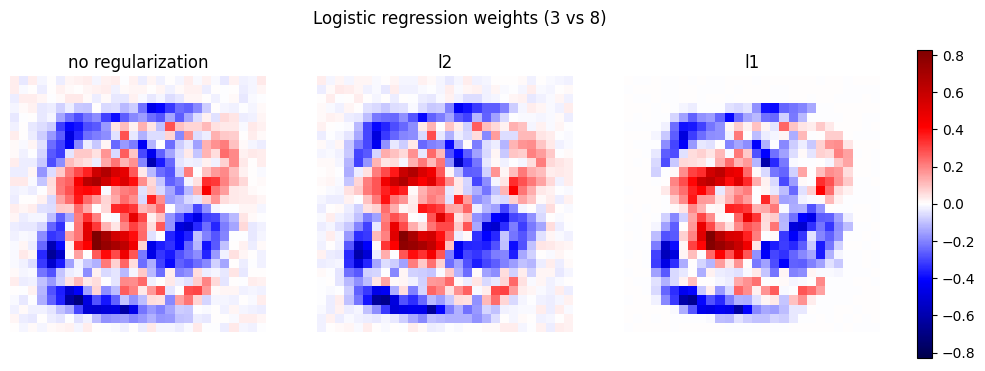

In [22]:
binary_models = [("no regularization", model_none), ("l2", model_l2), ("l1", model_l1)] # save results

weights = []
for name, m in binary_models:
    w = m.linear.weight.detach().cpu().view(28, 28)
    weights.append(w)

vmax = max(w.abs().max().item() for w in weights)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, m), w in zip(axes, binary_models, weights):
    im = ax.imshow(w, cmap="seismic", vmin=-vmax, vmax=vmax)

    ax.set_title(name)
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.04)

plt.suptitle("Logistic regression weights (3 vs 8)")
plt.show()

In [23]:
import pandas as pd
# AI-assisted: ChatGPT was used to help format the model norm results into a pandas DataFrame;
# results and calculations are verified by the author.
rows = []

for name, m in binary_models:
    w = m.linear.weight.detach().cpu().flatten()

    rows.append({
        "model": name,
        "L1 norm": round(w.abs().sum().item(), 2),
        "L2 norm": round(w.norm().item(), 2),
        "Inf norm": round(w.abs().max().item(), 4),
        "zeros": (w.abs() < 1e-6).sum().item()
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,104.78,5.71,0.8287,0
1,l2,101.89,5.57,0.8033,0
2,l1,84.34,5.23,0.8247,18


What we see:
1. The $\ell^1$-regularized weights are **sparse**: many pixels are exactly or close to zero;
2. The $\ell^1$-regularized model has the lowest $\|w\|_1$, which should mean a more robust model (to adversarial examples).

## 1.3 FGSM on the binary models
We now attack all three models with FGSM at increasing $\varepsilon$ and plot accuracy-vs-$\varepsilon$ curves.


In [24]:
EPSILONS_MNIST = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25]
# Accuracy for different epsilons
results_bin = {}
for name, m in binary_models:
  accs = []
  for eps in EPSILONS_MNIST:
        if eps == 0.0:
            acc = eval_binary(m, test_loader_bin) # clean accuracy
        else:
            acc = evaluate_fgsm_binary(m, test_loader_bin, eps)
        accs.append(acc)
  results_bin[name] = accs
  print(name, ":", *[round(a, 3) for a in accs])




no regularization : 0.968 0.934 0.779 0.38 0.111 0.018 0.001
l2 : 0.97 0.939 0.795 0.405 0.125 0.021 0.001
l1 : 0.967 0.943 0.825 0.488 0.192 0.04 0.004


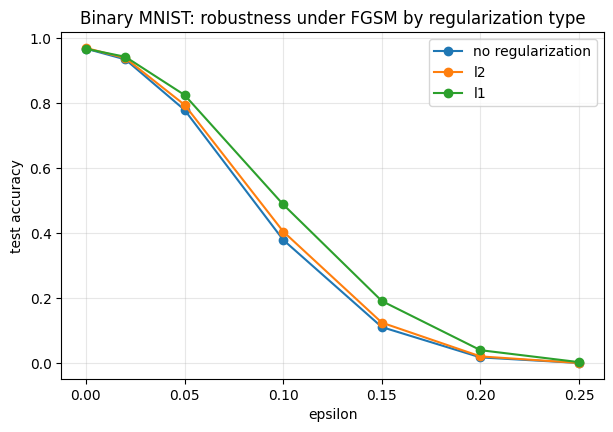

In [25]:
# plot accuracy vs attack strength
plt.figure(figsize=(7, 4.5))
for name, accs in results_bin.items():
    plt.plot(EPSILONS_MNIST, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Binary MNIST: robustness under FGSM by regularization type")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We can see that accuracy degrades significantly.

## 1.4 Comparison with random noise
We compare FGSM to two noise implementations all bounded by $\varepsilon$:

- **Gaussian noise**: the noise is centered around 0, so pixels can either increase or decrease. Its standard deviation is set to ε/3, which means most pixel changes are much smaller than ε.
- **Random sign noise**: every pixel moved by exactly $\pm\varepsilon$ (random sign).

In [26]:
gaussian_accs = []

for eps in EPSILONS_MNIST:
    if eps == 0:
        acc = eval_binary(model_none, test_loader_bin)
    else:
        acc = evaluate_noise_binary(
            model_none,
            test_loader_bin,
            eps,
            gaussian_noise_attack
        )
    gaussian_accs.append(acc)

results_bin["gaussian noise"] = gaussian_accs
print("gaussian noise:", *[round(a, 3) for a in gaussian_accs])


random_sign_accs = []

for eps in EPSILONS_MNIST:
    if eps == 0:
        acc = eval_binary(model_none, test_loader_bin)
    else:
        acc = evaluate_noise_binary(
            model_none,
            test_loader_bin,
            eps,
            random_sign_attack
        )
    random_sign_accs.append(acc)

results_bin["random sign noise"] = random_sign_accs
print("random sign noise:", *[round(a, 3) for a in random_sign_accs])

gaussian noise: 0.968 0.968 0.967 0.967 0.966 0.964 0.964
random sign noise: 0.968 0.967 0.965 0.962 0.943 0.927 0.883


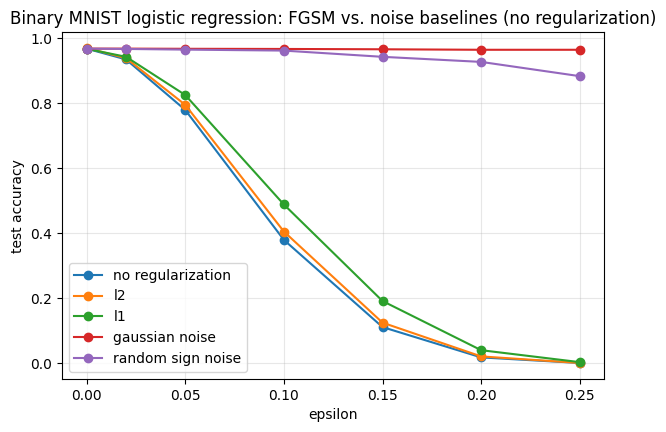

In [27]:
plt.figure(figsize=(7, 4.5))
for name, accs in results_bin.items():
    plt.plot(EPSILONS_MNIST, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Binary MNIST logistic regression: FGSM vs. noise baselines (no regularization)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Noise does not degrade the model nearly as much as FGSM does.

### Comparing the theoretical max change to actual change
$\varepsilon\|w\|_1$ is the theoretical maximum that we are able to compute directly. We check how close FGSM gets to that maximum as well as our noise implementations.

In [28]:
def compare_output_change(model, x, y, epsilon, noise_fns):

    # theoretical maximum change
    w = model.linear.weight.detach().flatten()
    theoretical_max = epsilon * w.abs().sum().item()

    x = x.to(device)
    y = y.to(device).float()

    # model output before sigmoid
    clean_output = model.linear(x.view(x.size(0), -1)).squeeze(-1)

    # FGSM
    x_fgsm = fgsm_attack(model, x, y, epsilon, bce)
    fgsm_output = model.linear(x_fgsm.view(x_fgsm.size(0), -1)).squeeze(-1)

    fgsm_change = (fgsm_output - clean_output).abs().mean().item()
    fgsm_percent = (fgsm_change / theoretical_max) * 100

    rows = []

    rows.append({
        "type": "theoretical max",
        "mean change": round(theoretical_max, 4),
        "% of max": 100
    })

    rows.append({
        "type": "FGSM",
        "mean change": round(fgsm_change, 4),
        "% of max": round(fgsm_percent, 1)
    })

    # noise attacks
    for name, noise_fn in noise_fns.items():

        x_noise = noise_fn(x, epsilon)
        noise_output = model.linear(
            x_noise.view(x_noise.size(0), -1)
        ).squeeze(-1)

        noise_change = (noise_output - clean_output).abs().mean().item()
        noise_percent = (noise_change / theoretical_max) * 100

        rows.append({
            "type": name,
            "mean change": round(noise_change, 4),
            "% of max": round(noise_percent, 1)
        })

    return pd.DataFrame(rows)

x_batch, y_batch = next(iter(test_loader_bin))

compare_output_change(
    model_none,
    x_batch,
    y_batch,
    epsilon=0.15,
    noise_fns={
        "gaussian noise": gaussian_noise_attack,
        "random sign noise": random_sign_attack
    }
)

,type,mean change,% of max
0,theoretical max,15.7167,100.0
1,FGSM,9.8257,62.5
2,gaussian noise,0.3590,2.3
3,random sign noise,1.3502,8.6


## 1.5 Visualizing adversarial examples

We display clean images, their perturbed versions and the perturbations themselves (no regularization).

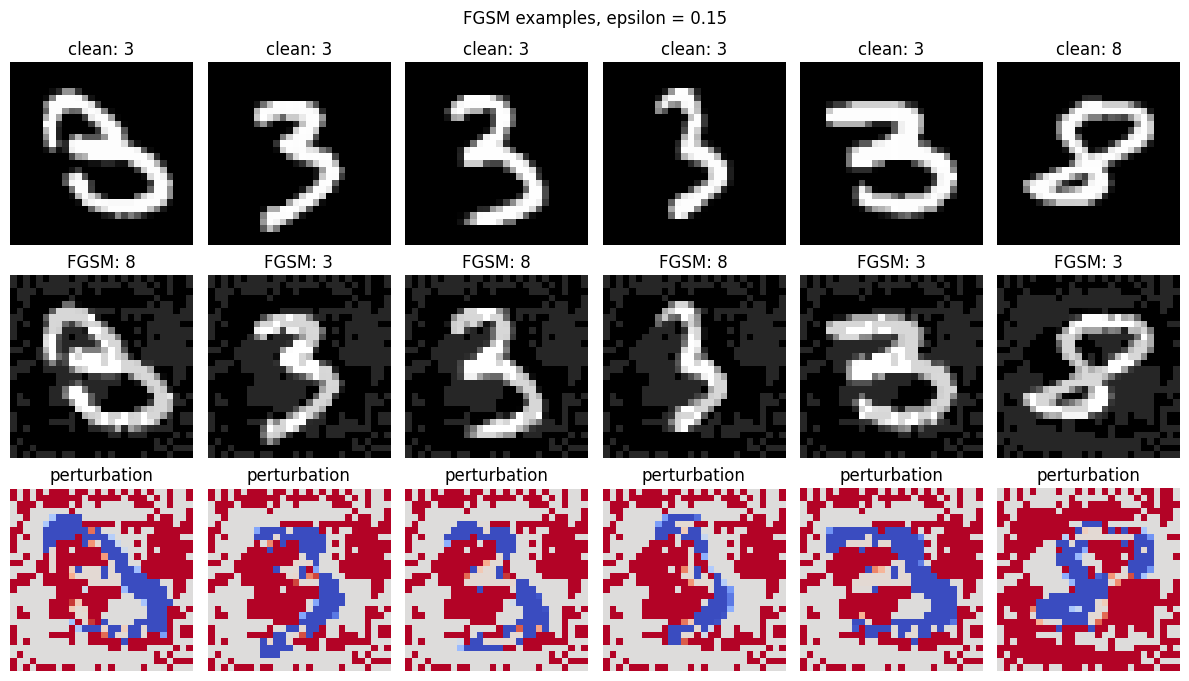

In [29]:
def show_binary_adversarials(model, loader, epsilon, n=6):

    model.eval()

    # get first batch and take first n images
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n].to(device)

    # create adversarial examples
    x_adv = fgsm_attack(model, x, y, epsilon, bce)

    # predictions before and after FGSM
    with torch.no_grad():
        pred_clean = (model(x) > 0.5).long().cpu()
        pred_adv = (model(x_adv) > 0.5).long().cpu()

    labels = {0: "3", 1: "8"}

    # move images back to CPU for plotting
    x = x.cpu()
    x_adv = x_adv.cpu()

    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):

        # clean image
        axes[0, i].imshow(x[i].view(28, 28), cmap="gray")
        axes[0, i].set_title("clean: " + labels[pred_clean[i].item()])
        axes[0, i].axis("off")

        # adversarial image
        axes[1, i].imshow(x_adv[i].view(28, 28), cmap="gray")
        axes[1, i].set_title("FGSM: " + labels[pred_adv[i].item()])
        axes[1, i].axis("off")

        # perturbation
        axes[2, i].imshow(perturbation[i].view(28, 28), cmap="coolwarm")
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("FGSM examples, epsilon = " + str(epsilon))
    plt.tight_layout()
    plt.show()


show_binary_adversarials(
    model_none,
    test_loader_bin,
    epsilon=0.15
)

Each perturbation column shows what FGSM added to an image (red = pixel became brighter,
blue = darker). Notice the perturbations look basically the same across all
six images. The pattern also traces the
digit's shape, i.e. the pixels the model actually uses to tell 3s from 8s.

## 1.6 Adversarial training

Here, we use a method called FGSM adversarial training (Goodfellow et al., 2015).

**How it works:** For each batch, we train the model using both the original images and adversarial versions of those images.

1. FGSM is applied to the current model to create an adversarial version of the batch.
2. We calculate the cross-entropy loss on the clean images and on the adversarial images.
3. The two losses are combined using a weighted average (`adv_weight=0.5`)


In [30]:
print("Training FGSM adversarial model:")
model_adv = train_binary_adversarial(train_loader_bin, epsilon=0.15, adv_weight=0.5, epochs=15)
clean_acc = eval_binary(model_adv, test_loader_bin)

print("Clean test adversarial accuracy:", round(clean_acc, 4))

Training FGSM adversarial model:
epoch 1 | loss: 0.4582 | train acc (clean): 0.9182
epoch 5 | loss: 0.3714 | train acc (clean): 0.9322
epoch 10 | loss: 0.3668 | train acc (clean): 0.9326
epoch 15 | loss: 0.3695 | train acc (clean): 0.9324
Clean test adversarial accuracy: 0.9446


In [31]:
# add adversarial training results
adv_accs = []

for eps in EPSILONS_MNIST:
    if eps == 0:
        acc = eval_binary(model_adv, test_loader_bin)
    else:
        acc = evaluate_fgsm_binary(model_adv, test_loader_bin, eps)

    adv_accs.append(acc)

results_bin["adversarial training"] = adv_accs

# show results
print("epsilon:", *EPSILONS_MNIST)

for name, accs in results_bin.items():
    print(name, ":",  *[round(a, 3) for a in accs])

epsilon: 0.0 0.02 0.05 0.1 0.15 0.2 0.25
no regularization : 0.968 0.934 0.779 0.38 0.111 0.018 0.001
l2 : 0.97 0.939 0.795 0.405 0.125 0.021 0.001
l1 : 0.967 0.943 0.825 0.488 0.192 0.04 0.004
gaussian noise : 0.968 0.968 0.967 0.967 0.966 0.964 0.964
random sign noise : 0.968 0.967 0.965 0.962 0.943 0.927 0.883
adversarial training : 0.945 0.935 0.916 0.868 0.782 0.657 0.468


Let's now check whether adversarial training also reduces $|w|_1$ in a similar way to L1 regularization. If it does, this could help explain why adversarial training improves the robustness of logistic regression models against adversarial attacks.


In [32]:
binary_models_all = binary_models + [("adversarial training", model_adv)]

rows = []

for name, model in binary_models_all:
    w = model.linear.weight.detach().cpu().flatten()

    l1_norm = w.abs().sum().item()
    l2_norm = w.norm().item()
    inf_norm = w.abs().max().item()
    n_zero = (w.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,104.78,5.71,0.8287,0
1,l2,101.89,5.57,0.8033,0
2,l1,84.34,5.23,0.8247,18
3,adversarial training,16.75,3.07,1.2156,0


# Part 2 - Multiclass (softmax) logistic regression on MNIST

We now use all ten digits with the softmax

In [33]:
mc_none = train_multiclass(train_loader, reg_type=None)

print("")

mc_l2 = train_multiclass(train_loader, reg_type="l2", reg_strength=1e-04)

print("")

mc_l1 = train_multiclass(train_loader, reg_type="l1", reg_strength=1e-04)

print("")

mc_models = [("no regularization", mc_none), ("l2", mc_l2), ("l1", mc_l1)]
print("Test accuracy (none):", round(eval_multiclass(mc_none, test_loader), 4))
print("Test accuracy (l2):", round(eval_multiclass(mc_l2, test_loader), 4))
print("Test accuracy (l1):", round(eval_multiclass(mc_l1, test_loader), 4))

epoch 1 | loss: 0.4069 | train acc: 0.8853
epoch 5 | loss: 0.2798 | train acc: 0.9216
epoch 10 | loss: 0.2652 | train acc: 0.9259
epoch 15 | loss: 0.2581 | train acc: 0.9277

epoch 1 | loss: 0.4125 | train acc: 0.8848
epoch 5 | loss: 0.2883 | train acc: 0.9213
epoch 10 | loss: 0.2796 | train acc: 0.9256
epoch 15 | loss: 0.2755 | train acc: 0.9276

epoch 1 | loss: 0.4513 | train acc: 0.8827
epoch 5 | loss: 0.3441 | train acc: 0.9184
epoch 10 | loss: 0.3375 | train acc: 0.922
epoch 15 | loss: 0.3348 | train acc: 0.9221

Test accuracy (none): 0.9262
Test accuracy (l2): 0.9255
Test accuracy (l1): 0.9208


## 2.1 Looking at the weight vectors

With ten classes there are ten weight vectors. We display the weight matrix rows as images, and print out the $\ell^1$ and the $\ell^2$ norms of the weights as well as the features equal to zero.

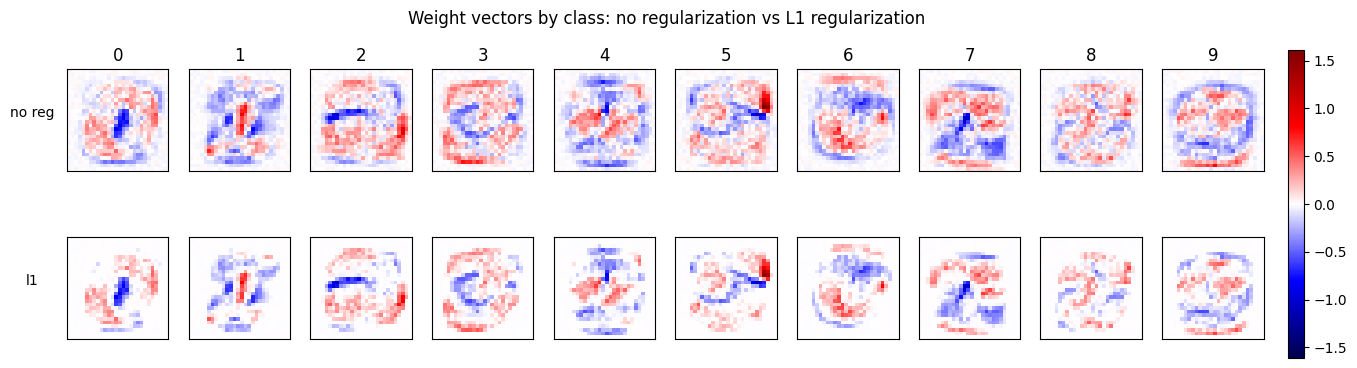

In [34]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

# get all weights first so both rows use the same color scale
all_weights = []

for k in range(10):
    all_weights.append(mc_none.linear.weight[k].detach().cpu())
    all_weights.append(mc_l1.linear.weight[k].detach().cpu())

all_weights = torch.stack(all_weights)
vmax = all_weights.abs().max().item()

models_to_show = [("no reg", mc_none), ("l1", mc_l1)]

for row, (name, model) in enumerate(models_to_show):
    for k in range(10):
        w = model.linear.weight[k].detach().cpu().view(28, 28)

        im = axes[row, k].imshow(
            w,
            cmap="seismic",
            vmin=-vmax,
            vmax=vmax
        )

        axes[row, k].set_xticks([])
        axes[row, k].set_yticks([])

        if row == 0:
            axes[row, k].set_title(str(k))

    axes[row, 0].set_ylabel(name, rotation=0, labelpad=25)

fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
plt.suptitle("Weight vectors by class: no regularization vs L1 regularization")
plt.show()

In [35]:
rows = []

for name, model in mc_models:
    W = model.linear.weight.detach().cpu().flatten()

    l1_norm = W.abs().sum().item()
    l2_norm = W.norm().item()
    inf_norm = W.abs().max().item()
    n_zero = (W.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,1058.24,18.02,1.6110,0
1,l2,945.40,16.24,1.4056,0
2,l1,574.07,13.66,1.4762,305


## 2.2 FGSM on the multiclass models
Same idea as 1.3

In [36]:

results_mc = {}
for name, m in mc_models:
    accs = []
    for eps in EPSILONS_MNIST:
        if eps == 0.0:
            accs.append(eval_multiclass(m, test_loader)) # clean accuracy
        else:
            a = evaluate_fgsm_multiclass(m, test_loader, eps)
            accs.append(a)
    results_mc[name] = accs
    print(name, *[round(a, 3) for a in accs])

no regularization 0.926 0.83 0.478 0.065 0.004 0.001 0.0
l2 0.925 0.84 0.536 0.086 0.007 0.0 0.0
l1 0.921 0.862 0.68 0.218 0.04 0.005 0.0


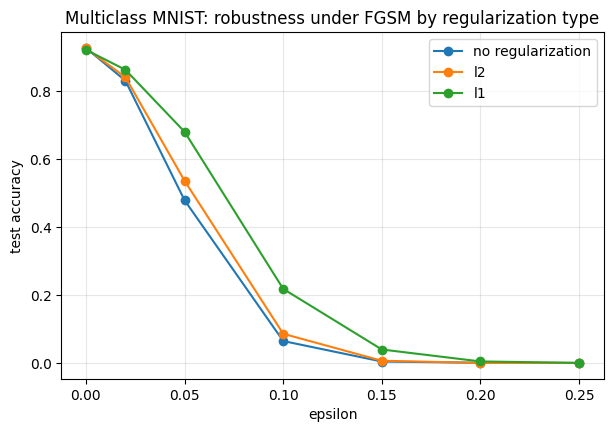

In [37]:
# plot accuracy vs attack strength
plt.figure(figsize=(7, 4.5))
for name, accs in results_mc.items():
    plt.plot(EPSILONS_MNIST, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass MNIST: robustness under FGSM by regularization type")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.3 Comparison with random noise

In [38]:
gaussian_accs = []

for eps in EPSILONS_MNIST:
    if eps == 0.0:
        acc = eval_multiclass(mc_none, test_loader)
    else:
        acc = evaluate_noise_multiclass(
            mc_none,
            test_loader,
            eps,
            gaussian_noise_attack
        )
    gaussian_accs.append(acc)

results_mc["gaussian noise"] = gaussian_accs
print("gaussian noise:", *[round(a, 3) for a in gaussian_accs])

random_sign_accs = []

for eps in EPSILONS_MNIST:

    if eps == 0.0:
        acc = eval_multiclass(mc_none, test_loader)

    else:
        acc = evaluate_noise_multiclass(
            mc_none,
            test_loader,
            eps,
            random_sign_attack
        )
    random_sign_accs.append(acc)

results_mc["random sign noise"] = random_sign_accs

print("random sign noise:", *[round(a, 3) for a in random_sign_accs])

gaussian noise: 0.926 0.926 0.926 0.925 0.923 0.92 0.916
random sign noise: 0.926 0.925 0.922 0.896 0.812 0.711 0.621


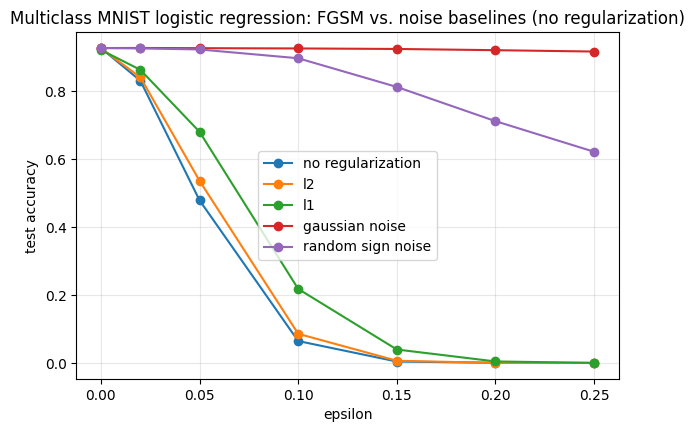

In [39]:
plt.figure(figsize=(7, 4.5))
for name, accs in results_mc.items():
    plt.plot(EPSILONS_MNIST, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass MNIST logistic regression: FGSM vs. noise baselines (no regularization)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Comparing the theoretical max change to the actual change
Since each class has its own row of $W$, the per-class theoretical max is averaged into a single number, so the output matches the binary version's shape.

In [40]:
def compare_output_change_multiclass(model, x, y, epsilon, noise_fns):

    # average theoretical maximum change across classes
    W = model.linear.weight.detach()
    theoretical_max = epsilon * W.abs().sum().item() / W.size(0)

    x = x.to(device)
    y = y.to(device)

    # clean logits
    x_flat = x.view(x.size(0), -1)
    clean_output = model.linear(x_flat)

    # FGSM
    x_fgsm = fgsm_attack(model, x, y, epsilon, F.cross_entropy)

    x_fgsm_flat = x_fgsm.view(x_fgsm.size(0), -1)
    fgsm_output = model.linear(x_fgsm_flat)

    fgsm_change = (fgsm_output - clean_output).abs().mean().item()
    fgsm_percent = (fgsm_change / theoretical_max) * 100

    rows = []

    rows.append({
        "type": "theoretical max",
        "mean change": round(theoretical_max, 4),
        "% of max": 100
    })

    rows.append({
        "type": "FGSM",
        "mean change": round(fgsm_change, 4),
        "% of max": round(fgsm_percent, 1)
    })

    # noise attacks
    for name, noise_fn in noise_fns.items():

        x_noise = noise_fn(x, epsilon)

        x_noise_flat = x_noise.view(x_noise.size(0), -1)
        noise_output = model.linear(x_noise_flat)

        noise_change = (noise_output - clean_output).abs().mean().item()
        noise_percent = (noise_change / theoretical_max) * 100

        rows.append({
            "type": name,
            "mean change": round(noise_change, 4),
            "% of max": round(noise_percent, 1)
        })

    return pd.DataFrame(rows)
x_batch, y_batch = next(iter(test_loader))

compare_output_change_multiclass(
    mc_none,
    x_batch,
    y_batch,
    epsilon=0.15,
    noise_fns={
        "gaussian noise": gaussian_noise_attack,
        "random sign noise": random_sign_attack
    }
)

,type,mean change,% of max
0,theoretical max,15.8735,100.0
1,FGSM,2.9848,18.8
2,gaussian noise,0.3906,2.5
3,random sign noise,1.3870,8.7


## 2.4 Visualizing adversarial examples

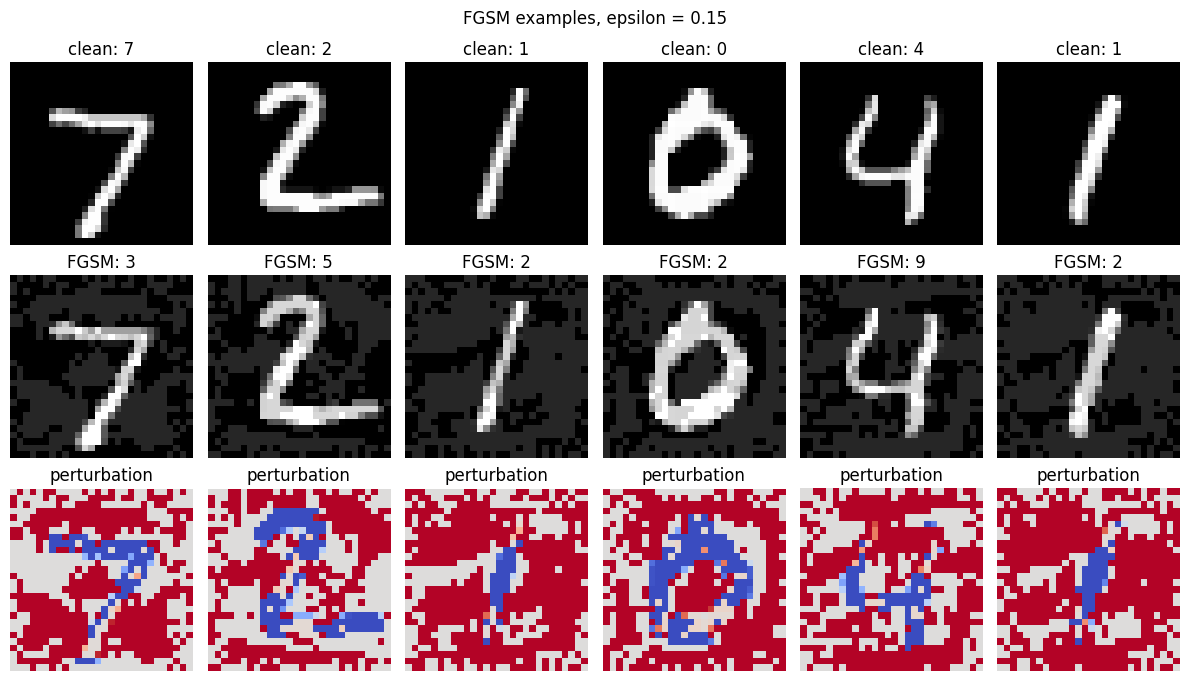

In [41]:
def show_multiclass_adversarials(model, loader, epsilon, n=6):

    model.eval()

    # get first batch and take first n images
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n].to(device)

    # create adversarial examples
    x_adv = fgsm_attack(model, x, y, epsilon, F.cross_entropy)

    # predictions before and after FGSM
    with torch.no_grad():
        pred_clean = model(x).argmax(1).cpu()
        pred_adv = model(x_adv).argmax(1).cpu()

    # move images back to CPU for plotting
    x = x.cpu()
    x_adv = x_adv.cpu()

    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):

        # clean image
        axes[0, i].imshow(x[i].view(28, 28), cmap="gray")
        axes[0, i].set_title("clean: " + str(pred_clean[i].item()))
        axes[0, i].axis("off")

        # adversarial image
        axes[1, i].imshow(x_adv[i].view(28, 28), cmap="gray")
        axes[1, i].set_title("FGSM: " + str(pred_adv[i].item()))
        axes[1, i].axis("off")

        # perturbation
        axes[2, i].imshow(
            perturbation[i].view(28, 28),
            cmap="coolwarm"
        )
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("FGSM examples, epsilon = " + str(epsilon))
    plt.tight_layout()
    plt.show()


show_multiclass_adversarials(
    mc_none,
    test_loader,
    epsilon=0.15
)

## 2.5 Adversarial training

In [42]:
print("Training FGSM adversarial model:")
mc_adv = train_multiclass_adversarial(train_loader, epsilon=0.15, adv_weight=0.5, epochs=15)
clean_acc = eval_multiclass(mc_adv, test_loader)
print("Clean test adversarial accuracy:", round(clean_acc, 4))

Training FGSM adversarial model:
epoch 1 | loss: 1.0607 | train acc (clean): 0.8482
epoch 5 | loss: 0.9941 | train acc (clean): 0.8601
epoch 10 | loss: 0.993 | train acc (clean): 0.8606
epoch 15 | loss: 0.9942 | train acc (clean): 0.8606
Clean test adversarial accuracy: 0.8709


In [43]:
# add adversarial training results
adv_accs = []

for eps in EPSILONS_MNIST:
    if eps == 0.0:
        #acc = eval_multiclass(mc_adv, test_loader_bin)
        acc = clean_acc
    else:
        acc = evaluate_fgsm_multiclass(mc_adv, test_loader, eps)

    adv_accs.append(acc)

results_mc["adversarial training"] = adv_accs

# show results
print("epsilon:", *EPSILONS_MNIST)

for name, accs in results_mc.items():
    print(name, *[round(a, 3) for a in accs])

epsilon: 0.0 0.02 0.05 0.1 0.15 0.2 0.25
no regularization 0.926 0.83 0.478 0.065 0.004 0.001 0.0
l2 0.925 0.84 0.536 0.086 0.007 0.0 0.0
l1 0.921 0.862 0.68 0.218 0.04 0.005 0.0
gaussian noise 0.926 0.926 0.926 0.925 0.923 0.92 0.916
random sign noise 0.926 0.925 0.922 0.896 0.812 0.711 0.621
adversarial training 0.871 0.845 0.794 0.678 0.513 0.317 0.126


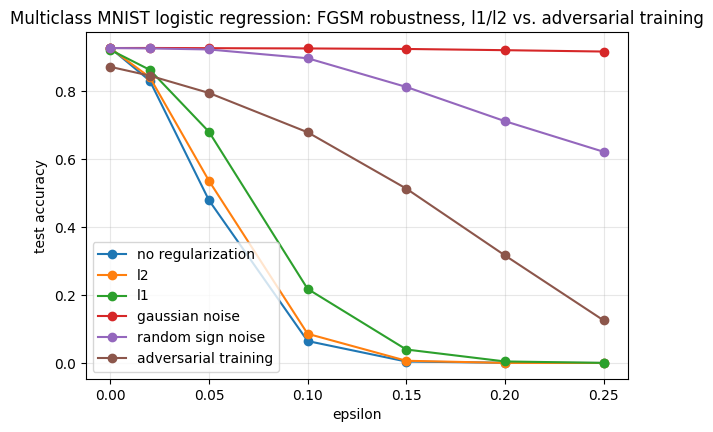

In [44]:
# re-plot with all four models together
plt.figure(figsize=(7, 4.5))
for name, accs in results_mc.items():
    plt.plot(EPSILONS_MNIST, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass MNIST logistic regression: FGSM robustness, l1/l2 vs. adversarial training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
# does adversarial training also shrink W_1, the way L1 does?
mc_models_all = mc_models + [("adversarial training", mc_adv)]

rows = []

for name, model in mc_models_all:
    W = model.linear.weight.detach().cpu().flatten()

    l1_norm = W.abs().sum().item()
    l2_norm = W.norm().item()
    inf_norm = W.abs().max().item()
    n_zero = (W.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,1058.24,18.02,1.6110,0
1,l2,945.40,16.24,1.4056,0
2,l1,574.07,13.66,1.4762,305
3,adversarial training,239.63,6.62,1.0189,2


# Part 3 - Binary logistic regression on STL-10

So far we studied logistic regression on MNIST, where each input is a $784$-dimensional vector. We now repeat the analysis on STL-10, where each image is $3 \times 96 \times 96 = 27648$-dimensional.   

**A warning up front about accuracy.** A linear model on raw STL-10 pixels is a poor
*classifier* but we still consider it for our adversarial comparisons.

We start by loading the STL-10 dataset and preparing the training and test sets.


In [46]:
from data import load_stl10

stl = load_stl10()

STL_DIM = stl["STL_DIM"]

stl_train = stl["stl_train"]
stl_test = stl["stl_test"]

stl_train_bin = stl["stl_train_bin"]
stl_test_bin = stl["stl_test_bin"]

stl_train_loader_bin = stl["stl_train_loader_bin"]
stl_test_loader_bin = stl["stl_test_loader_bin"]

stl_train_loader = stl["stl_train_loader"]
stl_test_loader = stl["stl_test_loader"]

stl_name_a = stl["stl_name_a"]
stl_name_b = stl["stl_name_b"]
# the functions defined for training on the MNIST dataset can be reused for STL-10 as well

100%|██████████| 2.64G/2.64G [08:12<00:00, 5.36MB/s]


## 3.1 Binary logistic regression on STL-10

We train a binary logistic regression model, where we choose images of cats and dogs for the two classes to be identified. We chose cats and dogs because these classes could easily be confused by the models

We can reuse the models and the evaluation function since it never assumes input shape anywhere.

In [47]:
# lr=0.05 diverges here
# 0.0005 seems stable
print("Training unregularized model:")
stl_model_none = train_binary_logreg(stl_train_loader_bin, reg_type=None, in_features=STL_DIM, lr=0.0005, epochs=60)

print("")

print("Training l2-regularized model:")
stl_model_l2 = train_binary_logreg(stl_train_loader_bin, reg_type="l2", reg_strength=1e-04, in_features=STL_DIM, lr=0.0005, epochs=60)

print("")

print("Training l1-regularized model:")
stl_model_l1 = train_binary_logreg(stl_train_loader_bin, reg_type="l1", reg_strength=1e-04, in_features=STL_DIM,  lr=0.0005, epochs=60)

print("")

print("Test accuracy (none):", round(eval_binary(stl_model_none, stl_test_loader_bin), 4))
print("Test accuracy (l2):", round(eval_binary(stl_model_l2, stl_test_loader_bin), 4))
print("Test accuracy (l1):", round(eval_binary(stl_model_l1, stl_test_loader_bin), 4))

Training unregularized model:
epoch 1 | loss: 0.6999 | train acc: 0.484
epoch 5 | loss: 0.6903 | train acc: 0.551
epoch 10 | loss: 0.631 | train acc: 0.651
epoch 15 | loss: 0.6042 | train acc: 0.683
epoch 20 | loss: 0.6183 | train acc: 0.643
epoch 25 | loss: 0.601 | train acc: 0.664
epoch 30 | loss: 0.568 | train acc: 0.71
epoch 35 | loss: 0.5677 | train acc: 0.698
epoch 40 | loss: 0.5413 | train acc: 0.749
epoch 45 | loss: 0.5221 | train acc: 0.762
epoch 50 | loss: 0.5075 | train acc: 0.782
epoch 55 | loss: 0.5061 | train acc: 0.779
epoch 60 | loss: 0.5026 | train acc: 0.777

Training l2-regularized model:
epoch 1 | loss: 0.6995 | train acc: 0.491
epoch 5 | loss: 0.6682 | train acc: 0.594
epoch 10 | loss: 0.6473 | train acc: 0.617
epoch 15 | loss: 0.6015 | train acc: 0.69
epoch 20 | loss: 0.5804 | train acc: 0.722
epoch 25 | loss: 0.5707 | train acc: 0.729
epoch 30 | loss: 0.5531 | train acc: 0.757
epoch 35 | loss: 0.5378 | train acc: 0.782
epoch 40 | loss: 0.5469 | train acc: 0.732
e

## 3.2 Looking at the weights

The weight vector is now $(3, 96, 96)$, not $(28, 28)$. We normalize each channel's signed weights into a
color image directly

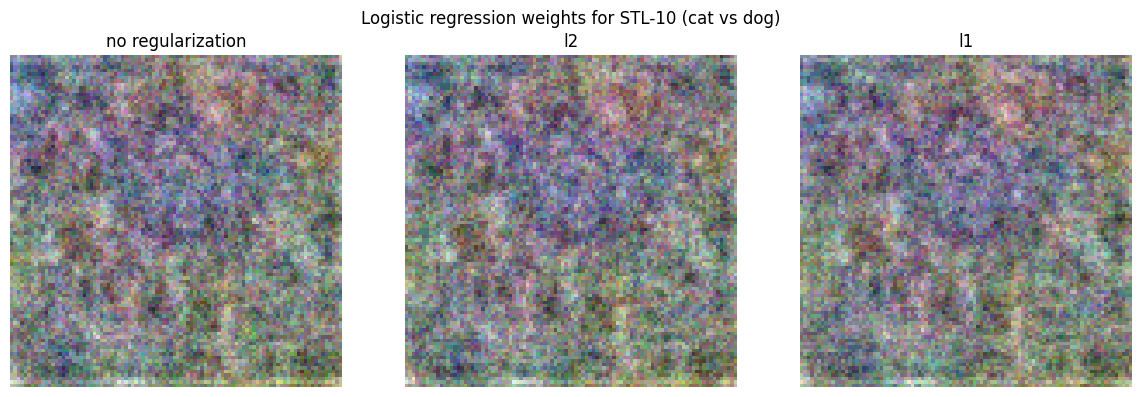

In [48]:
stl_models = [("no regularization", stl_model_none), ("l2", stl_model_l2), ("l1", stl_model_l1)]



# use the same scale for all models
all_weights = []

for name, model in stl_models:
    w = model.linear.weight.detach().cpu().view(3, 96, 96)
    all_weights.append(w)

vmax = max(w.abs().max().item() for w in all_weights)


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, model) in zip(axes, stl_models):

    # reshape weights back to RGB image shape
    w = model.linear.weight.detach().cpu().view(3, 96, 96)

    # scale weights to [0, 1] so they can be shown as an RGB image
    w_img = ((w / vmax) + 1) / 2
    w_img = w_img.permute(1, 2, 0).clamp(0, 1)

    ax.imshow(w_img)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Logistic regression weights for STL-10 (cat vs dog)")
plt.tight_layout()
plt.show()

In [49]:
rows = []

for name, model in stl_models:
    W = model.linear.weight.detach().cpu().flatten()

    l1_norm = W.abs().sum().item()
    l2_norm = W.norm().item()
    inf_norm = W.abs().max().item()
    n_zero = (W.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,117.21,0.87,0.0203,4
1,l2,116.83,0.87,0.0219,3
2,l1,111.27,0.84,0.0198,7


## 3.3 FGSM on the models

Reusing `evaluate_fgsm_binary` directly, it never assumed input shape anywhere.  


**Note on epsilon scale:** MNIST's epsilons degrade the model basically at the lowest epsilon. We use a smaller range below instead of reusing previously used epsilons.

In [50]:
# now decrease the scale of epsilons
EPSILONS_STL = [0, 0.002, 0.005, 0.01, 0.015, 0.02, 0.025]

# Accuracy for different epsilons
results_stl_bin = {}
for name, m in stl_models:
  accs = []
  for eps in EPSILONS_STL:
        if eps == 0.0:
            acc = eval_binary(m, stl_test_loader_bin) # clean accuracy
        else:
            acc = evaluate_fgsm_binary(m, stl_test_loader_bin, eps)
        accs.append(acc)
  results_stl_bin[name] = accs
  print(name, ":", *[round(a, 3) for a in accs])

no regularization : 0.586 0.456 0.284 0.124 0.036 0.009 0.003
l2 : 0.581 0.458 0.294 0.127 0.041 0.012 0.004
l1 : 0.589 0.461 0.301 0.136 0.044 0.013 0.004


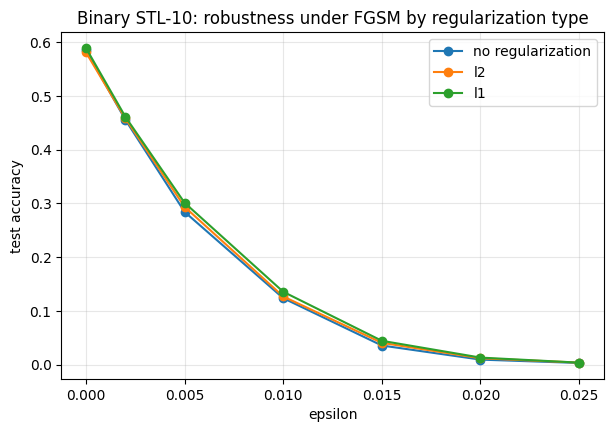

In [51]:
plt.figure(figsize=(7, 4.5))
for name, accs in results_stl_bin.items():
    plt.plot(EPSILONS_STL, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title(f"Binary STL-10: robustness under FGSM by regularization type")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.4 Comparison with random noise

In [52]:
gaussian_accs = []

for eps in EPSILONS_STL:
    if eps == 0:
        acc = eval_binary(stl_model_none, stl_test_loader_bin)
    else:
        acc = evaluate_noise_binary(
            stl_model_none,
            stl_test_loader_bin,
            eps,
            gaussian_noise_attack
        )
    gaussian_accs.append(acc)

results_stl_bin["gaussian noise"] = gaussian_accs
print("gaussian noise:", *[round(a, 3) for a in gaussian_accs])


random_sign_accs = []

for eps in EPSILONS_STL:
    if eps == 0.0:
        acc = eval_binary(stl_model_none, stl_test_loader_bin)
    else:
        acc = evaluate_noise_binary(
            stl_model_none,
            stl_test_loader_bin,
            eps,
            random_sign_attack
        )
    random_sign_accs.append(acc)

results_stl_bin["random sign noise"] = random_sign_accs
print("random sign noise:", *[round(a, 3) for a in random_sign_accs])

gaussian noise: 0.586 0.586 0.586 0.585 0.586 0.585 0.587
random sign noise: 0.586 0.586 0.585 0.584 0.586 0.583 0.585


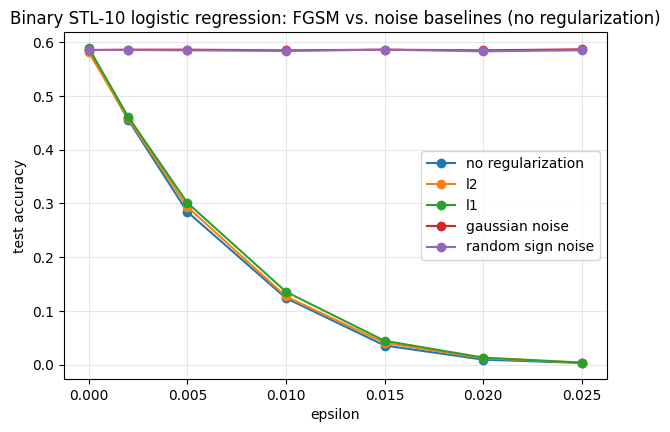

In [53]:
plt.figure(figsize=(7, 4.5))
for name, accs in results_stl_bin.items():
    plt.plot(EPSILONS_STL, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Binary STL-10 logistic regression: FGSM vs. noise baselines (no regularization)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Comparing the theoretical max change to the actual change

In [54]:
x_batch, y_batch = next(iter(stl_test_loader_bin))

compare_output_change(
    stl_model_none,
    x_batch,
    y_batch,
    epsilon=0.015,
    noise_fns={
        "gaussian noise": gaussian_noise_attack,
        "random sign noise": random_sign_attack
    }
)

,type,mean change,% of max
0,theoretical max,1.7582,100.0
1,FGSM,1.7447,99.2
2,gaussian noise,0.0038,0.2
3,random sign noise,0.0128,0.7


## 3.5 Visualizing adversarial examples

`fgsm_attack` itself is unchanged, but the display function needs a new version for RGB images. Also, since the accuracy of these models is low, we want to make sure each image chosen is actually classified correctly. Otherwise, most of them might me misclassified in the first place, and it's not an interesting representation.

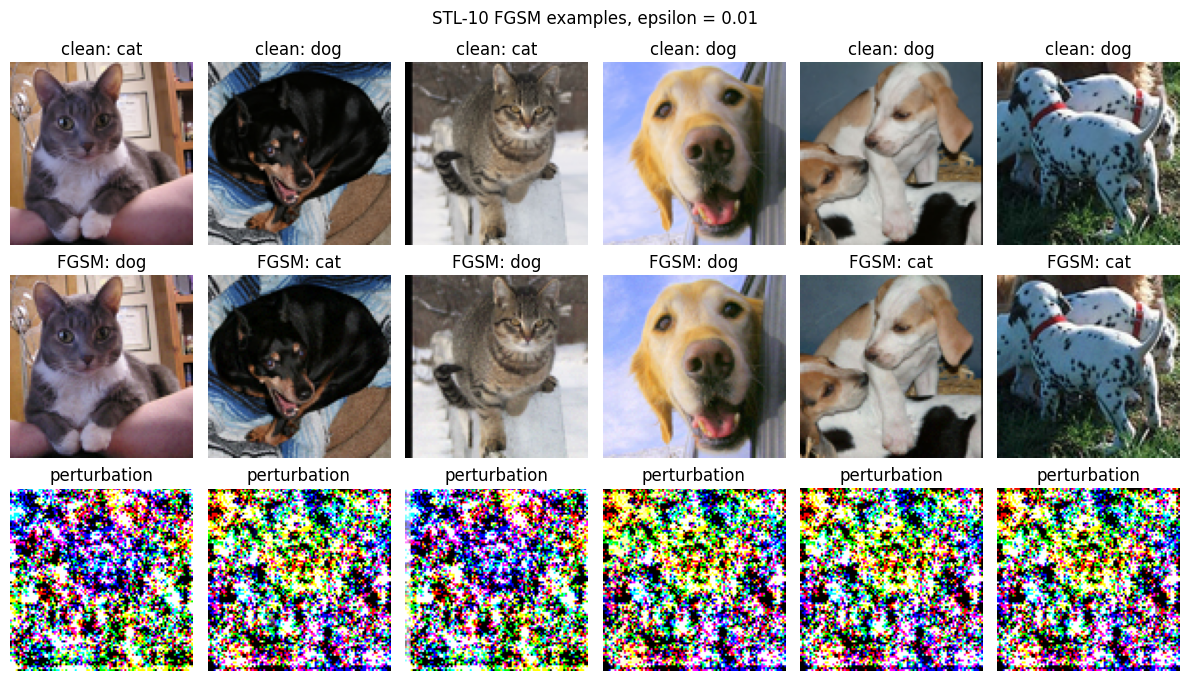

In [55]:
def show_stl_binary_adversarials(model, loader, epsilon, n=6):

    model.eval()

    # find correctly classified examples
    x_list = []
    y_list = []

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            pred = (model(x_batch) > 0.5).long()

        correct = pred == y_batch

        x_list.append(x_batch[correct])
        y_list.append(y_batch[correct])

        if sum(len(x) for x in x_list) >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    # create adversarial examples
    x_adv = fgsm_attack(model, x, y, epsilon, bce)

    with torch.no_grad():
        pred_clean = (model(x) > 0.5).long().cpu()
        pred_adv = (model(x_adv) > 0.5).long().cpu()

    labels = {
        0: stl_name_a,
        1: stl_name_b
    }

    x = x.cpu()
    x_adv = x_adv.cpu()

    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):

        # reshape back to RGB image
        clean_img = x[i].view(3, 96, 96).permute(1, 2, 0)
        adv_img = x_adv[i].view(3, 96, 96).permute(1, 2, 0)

        # scale perturbation so it can be shown as RGB
        pert = perturbation[i].view(3, 96, 96)
        pert_img = ((pert / epsilon) + 1) / 2
        pert_img = pert_img.permute(1, 2, 0).clamp(0, 1)

        axes[0, i].imshow(clean_img)
        axes[0, i].set_title("clean: " + labels[pred_clean[i].item()])
        axes[0, i].axis("off")

        axes[1, i].imshow(adv_img)
        axes[1, i].set_title("FGSM: " + labels[pred_adv[i].item()])
        axes[1, i].axis("off")

        axes[2, i].imshow(pert_img)
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("STL-10 FGSM examples, epsilon = " + str(epsilon))
    plt.tight_layout()
    plt.show()


show_stl_binary_adversarials(
    stl_model_none,
    stl_test_loader_bin,
    epsilon=0.01
)

## 3.6 Adversarial training

In [56]:
print("Training FGSM adversarial model:")
stl_model_adv = train_binary_adversarial(stl_train_loader_bin, epsilon=0.015, adv_weight=0.5, epochs=60, lr=0.0005, in_features=STL_DIM)
clean_acc = eval_binary(stl_model_adv, stl_test_loader_bin)

print("Clean test adversarial accuracy:", round(clean_acc, 4))

Training FGSM adversarial model:
epoch 1 | loss: 1.0927 | train acc (clean): 0.497
epoch 5 | loss: 0.9342 | train acc (clean): 0.602
epoch 10 | loss: 0.8326 | train acc (clean): 0.62
epoch 15 | loss: 0.7723 | train acc (clean): 0.626
epoch 20 | loss: 0.749 | train acc (clean): 0.604
epoch 25 | loss: 0.7221 | train acc (clean): 0.639
epoch 30 | loss: 0.6939 | train acc (clean): 0.657
epoch 35 | loss: 0.6848 | train acc (clean): 0.659
epoch 40 | loss: 0.7024 | train acc (clean): 0.614
epoch 45 | loss: 0.7256 | train acc (clean): 0.574
epoch 50 | loss: 0.6741 | train acc (clean): 0.678
epoch 55 | loss: 0.681 | train acc (clean): 0.655
epoch 60 | loss: 0.6673 | train acc (clean): 0.704
Clean test adversarial accuracy: 0.5831


In [57]:
# add adversarial training results
adv_accs = []

for eps in EPSILONS_STL:
    if eps == 0:
        acc = clean_acc
    else:
        acc = evaluate_fgsm_binary(stl_model_adv, stl_test_loader_bin, eps)

    adv_accs.append(acc)

results_stl_bin["adversarial training"] = adv_accs

# show results
print("epsilon:", *EPSILONS_STL)

for name, accs in results_stl_bin.items():
    print(name, *[round(a, 3) for a in accs])

epsilon: 0 0.002 0.005 0.01 0.015 0.02 0.025
no regularization 0.586 0.456 0.284 0.124 0.036 0.009 0.003
l2 0.581 0.458 0.294 0.127 0.041 0.012 0.004
l1 0.589 0.461 0.301 0.136 0.044 0.013 0.004
gaussian noise 0.586 0.586 0.586 0.585 0.586 0.585 0.587
random sign noise 0.586 0.586 0.585 0.584 0.586 0.583 0.585
adversarial training 0.583 0.546 0.501 0.439 0.374 0.321 0.265


In [58]:
stl_models_all = stl_models + [("adversarial training", stl_model_adv)]

rows = []

for name, model in stl_models_all:
    w = model.linear.weight.detach().cpu().flatten()

    l1_norm = w.abs().sum().item()
    l2_norm = w.norm().item()
    inf_norm = w.abs().max().item()
    n_zero = (w.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,117.21,0.87,0.0203,4
1,l2,116.83,0.87,0.0219,3
2,l1,111.27,0.84,0.0198,7
3,adversarial training,15.85,0.27,0.0165,564


# Part 4 - Multiclass logistic regression on STL-10

In [59]:
stl_mc_none = train_multiclass(stl_train_loader, reg_type=None, in_features=STL_DIM, lr=0.0005, epochs=60)

print("")

stl_mc_l2 = train_multiclass(stl_train_loader, reg_type="l2", reg_strength=1e-04, in_features=STL_DIM, lr=0.0005, epochs=60)

print("")

stl_mc_l1 = train_multiclass(stl_train_loader, reg_type="l1", reg_strength=1e-04, in_features=STL_DIM, lr=0.0005, epochs=60)

print("")

stl_mc_models = [("no regularization", stl_mc_none), ("l2", stl_mc_l2), ("l1", stl_mc_l1)]
print("Test accuracy (none):", round(eval_multiclass(stl_mc_none, stl_test_loader), 4))
print("Test accuracy (l2):", round(eval_multiclass(stl_mc_l2, stl_test_loader), 4))
print("Test accuracy (l1):", round(eval_multiclass(stl_mc_l1, stl_test_loader), 4))

epoch 1 | loss: 2.1091 | train acc: 0.223
epoch 5 | loss: 1.8132 | train acc: 0.3486
epoch 10 | loss: 1.6805 | train acc: 0.3966
epoch 15 | loss: 1.5964 | train acc: 0.4386
epoch 20 | loss: 1.527 | train acc: 0.4788
epoch 25 | loss: 1.4838 | train acc: 0.4952
epoch 30 | loss: 1.4453 | train acc: 0.5118
epoch 35 | loss: 1.4092 | train acc: 0.5234
epoch 40 | loss: 1.3522 | train acc: 0.562
epoch 45 | loss: 1.3069 | train acc: 0.5878
epoch 50 | loss: 1.2811 | train acc: 0.598
epoch 55 | loss: 1.2696 | train acc: 0.5876
epoch 60 | loss: 1.226 | train acc: 0.6084

epoch 1 | loss: 2.1073 | train acc: 0.213
epoch 5 | loss: 1.8401 | train acc: 0.3368
epoch 10 | loss: 1.6742 | train acc: 0.4078
epoch 15 | loss: 1.6297 | train acc: 0.4242
epoch 20 | loss: 1.5377 | train acc: 0.476
epoch 25 | loss: 1.5018 | train acc: 0.4776
epoch 30 | loss: 1.4468 | train acc: 0.507
epoch 35 | loss: 1.3938 | train acc: 0.5454
epoch 40 | loss: 1.3801 | train acc: 0.5394
epoch 45 | loss: 1.3331 | train acc: 0.5646

## 4.1 Looking at the weight norms

In [60]:
rows = []

for name, model in stl_mc_models:
    W = model.linear.weight.detach().cpu().flatten()

    l1_norm = W.abs().sum().item()
    l2_norm = W.norm().item()
    inf_norm = W.abs().max().item()
    n_zero = (W.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,1356.88,3.23,0.0329,38
1,l2,1355.08,3.23,0.0332,34
2,l1,1131.73,2.86,0.0350,123


## 4.2 FGSM on the models

In [61]:
results_stl_mc = {}
for name, m in stl_mc_models:
    accs = []
    for eps in EPSILONS_STL:
        if eps == 0.0:
            accs.append(eval_multiclass(m, stl_test_loader)) # clean accuracy
        else:
            a = evaluate_fgsm_multiclass(m, stl_test_loader, eps)
            accs.append(a)
    results_stl_mc[name] = accs
    print(name, *[round(a, 3) for a in accs])

no regularization 0.356 0.272 0.173 0.071 0.027 0.009 0.003
l2 0.338 0.257 0.167 0.07 0.025 0.008 0.003
l1 0.348 0.276 0.188 0.09 0.037 0.013 0.005


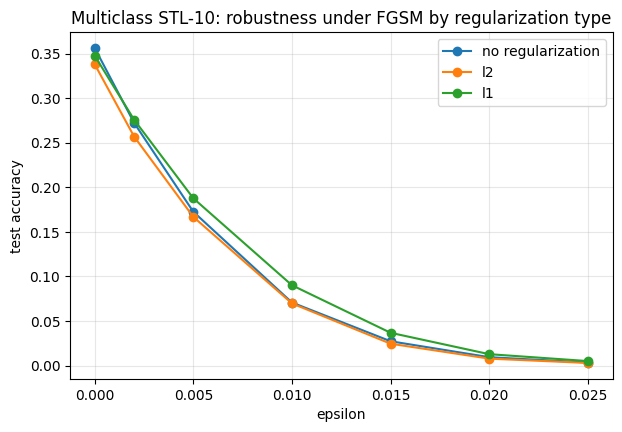

In [62]:
# plot accuracy vs attack strength
plt.figure(figsize=(7, 4.5))
for name, accs in results_stl_mc.items():
    plt.plot(EPSILONS_STL, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass STL-10: robustness under FGSM by regularization type")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.3 Comparison with random noise

In [63]:
gaussian_accs = []

for eps in EPSILONS_STL:
    if eps == 0.0:
        acc = eval_multiclass(stl_mc_none, stl_test_loader)
    else:
        acc = evaluate_noise_multiclass(
            stl_mc_none,
            stl_test_loader,
            eps,
            gaussian_noise_attack
        )
    gaussian_accs.append(acc)

results_stl_mc["gaussian noise"] = gaussian_accs
print("gaussian noise:", *[round(a, 3) for a in gaussian_accs])

random_sign_accs = []

for eps in EPSILONS_STL:

    if eps == 0.0:
        acc = eval_multiclass(stl_mc_none, stl_test_loader)

    else:
        acc = evaluate_noise_multiclass(
            stl_mc_none,
            stl_test_loader,
            eps,
            random_sign_attack
        )
    random_sign_accs.append(acc)

results_stl_mc["random sign noise"] = random_sign_accs

print("random sign noise:", *[round(a, 3) for a in random_sign_accs])

gaussian noise: 0.356 0.356 0.356 0.357 0.356 0.357 0.356
random sign noise: 0.356 0.356 0.356 0.357 0.357 0.356 0.357


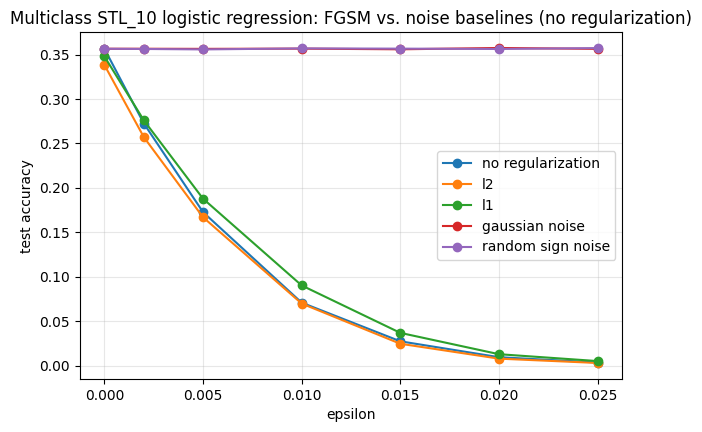

In [64]:
plt.figure(figsize=(7, 4.5))
for name, accs in results_stl_mc.items():
    plt.plot(EPSILONS_STL, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass STL_10 logistic regression: FGSM vs. noise baselines (no regularization)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Comparing the theoretical max change to the actual change

In [65]:
x_stl_mc_batch, y_stl_mc_batch = next(iter(stl_test_loader))

compare_output_change_multiclass(
    stl_mc_none,
    x_stl_mc_batch,
    y_stl_mc_batch,
    epsilon=0.015,
    noise_fns={
        "gaussian noise": gaussian_noise_attack,
        "random sign noise": random_sign_attack
    }
)

,type,mean change,% of max
0,theoretical max,2.0353,100.0
1,FGSM,0.3684,18.1
2,gaussian noise,0.0045,0.2
3,random sign noise,0.0143,0.7


## 4.4 Visualizing adversarial examples

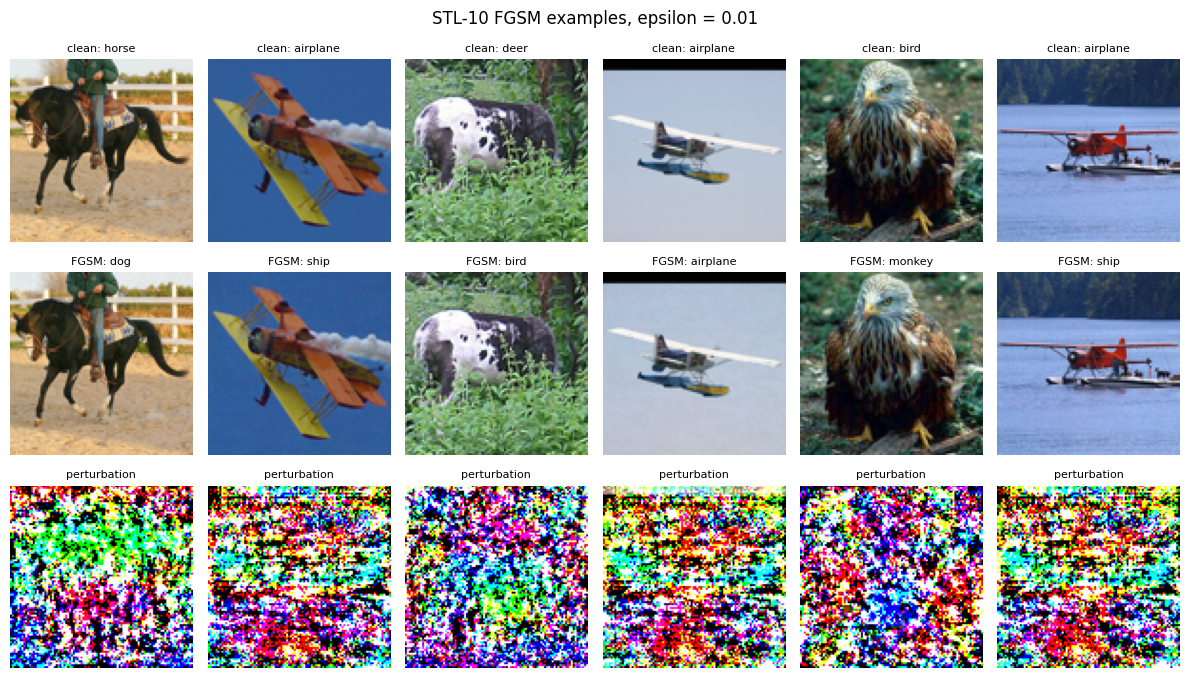

In [66]:
def show_stl_multiclass_adversarials(model, loader, epsilon, n=6):

    model.eval()

    # find correctly classified examples
    x_list = []
    y_list = []

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            pred = model(x_batch).argmax(1)

        correct = pred == y_batch

        x_list.append(x_batch[correct])
        y_list.append(y_batch[correct])

        # once we have n correct examples, stop searching
        if sum(len(x) for x in x_list) >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    # create adversarial examples
    x_adv = fgsm_attack(
        model,
        x,
        y,
        epsilon,
        F.cross_entropy
    )

    # predictions before and after FGSM
    with torch.no_grad():
        pred_clean = model(x).argmax(1).cpu()
        pred_adv = model(x_adv).argmax(1).cpu()

    class_names = stl_train.classes

    x = x.cpu()
    x_adv = x_adv.cpu()

    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):

        clean_img = x[i].permute(1, 2, 0)
        adv_img = x_adv[i].permute(1, 2, 0)

        # scale perturbation so it can be shown as RGB
        pert_img = ((perturbation[i] / epsilon) + 1) / 2
        pert_img = pert_img.permute(1, 2, 0).clamp(0, 1)

        axes[0, i].imshow(clean_img)
        axes[0, i].set_title(
            "clean: " + class_names[pred_clean[i].item()],
            fontsize=8
        )
        axes[0, i].axis("off")

        axes[1, i].imshow(adv_img)
        axes[1, i].set_title(
            "FGSM: " + class_names[pred_adv[i].item()],
            fontsize=8
        )
        axes[1, i].axis("off")

        axes[2, i].imshow(pert_img)
        axes[2, i].set_title("perturbation", fontsize=8)
        axes[2, i].axis("off")

    plt.suptitle("STL-10 FGSM examples, epsilon = " + str(epsilon))
    plt.tight_layout()
    plt.show()


show_stl_multiclass_adversarials(
    stl_mc_none,
    stl_test_loader,
    epsilon=0.01
)

## 4.5 Adversarial training

In [67]:
print("Training FGSM adversarial model (STL-10):")
stl_mc_adv = train_multiclass_adversarial(stl_train_loader, epsilon=0.015, adv_weight=0.5, epochs=60, in_features=STL_DIM, lr=0.0005)
clean_acc = eval_multiclass(stl_mc_adv, stl_test_loader)
print("Clean test adversarial accuracy:", round(clean_acc, 4))

Training FGSM adversarial model (STL-10):
epoch 1 | loss: 2.7094 | train acc (clean): 0.2064
epoch 5 | loss: 2.2656 | train acc (clean): 0.3586
epoch 10 | loss: 2.0721 | train acc (clean): 0.409
epoch 15 | loss: 1.9779 | train acc (clean): 0.425
epoch 20 | loss: 1.9257 | train acc (clean): 0.4314
epoch 25 | loss: 1.9006 | train acc (clean): 0.436
epoch 30 | loss: 1.8755 | train acc (clean): 0.4456
epoch 35 | loss: 1.8374 | train acc (clean): 0.4618
epoch 40 | loss: 1.8327 | train acc (clean): 0.462
epoch 45 | loss: 1.8749 | train acc (clean): 0.44
epoch 50 | loss: 1.834 | train acc (clean): 0.4492
epoch 55 | loss: 1.8394 | train acc (clean): 0.4562
epoch 60 | loss: 1.8198 | train acc (clean): 0.4546
Clean test adversarial accuracy: 0.3091


In [68]:
# add adversarial training results
adv_accs = []

for eps in EPSILONS_STL:
    if eps == 0.0:
        acc = clean_acc
    else:
        acc = evaluate_fgsm_multiclass(stl_mc_adv, stl_test_loader, eps)

    adv_accs.append(acc)

results_stl_mc["adversarial training"] = adv_accs

# show results
print("epsilon:", *EPSILONS_STL)

for name, accs in results_stl_mc.items():
    print(name, *[round(a, 3) for a in accs])

epsilon: 0 0.002 0.005 0.01 0.015 0.02 0.025
no regularization 0.356 0.272 0.173 0.071 0.027 0.009 0.003
l2 0.338 0.257 0.167 0.07 0.025 0.008 0.003
l1 0.348 0.276 0.188 0.09 0.037 0.013 0.005
gaussian noise 0.356 0.356 0.356 0.357 0.356 0.357 0.356
random sign noise 0.356 0.356 0.356 0.357 0.357 0.356 0.357
adversarial training 0.309 0.286 0.257 0.212 0.169 0.134 0.104


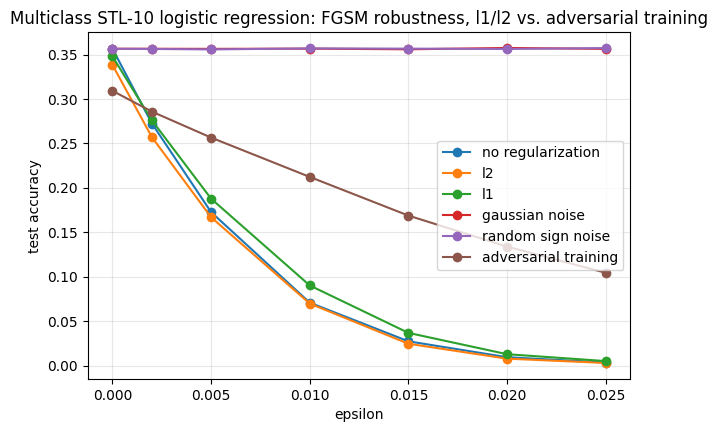

In [69]:
# re-plot with all four models together
plt.figure(figsize=(7, 4.5))
for name, accs in results_stl_mc.items():
    plt.plot(EPSILONS_STL, accs, marker="o", label=name)
plt.xlabel("epsilon")
plt.ylabel("test accuracy")
plt.title("Multiclass STL-10 logistic regression: FGSM robustness, l1/l2 vs. adversarial training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [70]:
# does adversarial training also shrink W_1, the way L1 does?
stl_mc_models_all = stl_mc_models + [("adversarial training", stl_mc_adv)]

rows = []

for name, model in stl_mc_models_all:
    W = model.linear.weight.detach().cpu().flatten()

    l1_norm = W.abs().sum().item()
    l2_norm = W.norm().item()
    inf_norm = W.abs().max().item()
    n_zero = (W.abs() < 1e-6).sum().item()

    rows.append({
        "model": name,
        "L1 norm": round(l1_norm, 2),
        "L2 norm": round(l2_norm, 2),
        "Inf norm": round(inf_norm, 4),
        "zeros": n_zero
    })

pd.DataFrame(rows)

,model,L1 norm,L2 norm,Inf norm,zeros
0,no regularization,1356.88,3.23,0.0329,38
1,l2,1355.08,3.23,0.0332,34
2,l1,1131.73,2.86,0.0350,123
3,adversarial training,526.72,1.52,0.0363,119


# Part 5 - Summary

## Save all the trained models and the results

In [71]:
# AI assistance: ChatGPT was used to check that this saving cell is consistent and includes all trained models.
import os

os.makedirs("saved_models", exist_ok=True)

models_to_save = {
    "model_none": model_none,
    "model_l2": model_l2,
    "model_l1": model_l1,
    "model_adv": model_adv,

    "mc_none": mc_none,
    "mc_l2": mc_l2,
    "mc_l1": mc_l1,
    "mc_adv": mc_adv,

    "stl_model_none": stl_model_none,
    "stl_model_l2": stl_model_l2,
    "stl_model_l1": stl_model_l1,
    "stl_model_adv": stl_model_adv,

    "stl_mc_none": stl_mc_none,
    "stl_mc_l2": stl_mc_l2,
    "stl_mc_l1": stl_mc_l1,
    "stl_mc_adv": stl_mc_adv
}

for name, model in models_to_save.items():
    torch.save(
        model.state_dict(),
        "saved_models/" + name + ".pt"
    )

print("Saved", len(models_to_save), "models to saved_models/")

Saved 16 models to saved_models/


In [72]:
import json

logreg_results = {
    "mnist_binary": {
        "epsilons": EPSILONS_MNIST,
        **results_bin
    },

    "mnist_multiclass": {
        "epsilons": EPSILONS_MNIST,
        **results_mc
    },

    "stl_binary": {
        "epsilons": EPSILONS_STL,
        **results_stl_bin
    },

    "stl_multiclass": {
        "epsilons": EPSILONS_STL,
        **results_stl_mc
    }
}

with open("logreg_results.json", "w") as f:
    json.dump(logreg_results, f, indent=2)

print("Saved logreg_results.json")

Saved logreg_results.json
